# Eksamen 2026 — MAMO2200 Avansert Modellering
## Tema: Midtpunktregelen og Legendre-approksimasjon

---

### Prosjektoppsett og reproduserbarhet

| Verktøy | Formål |
|---------|--------|
| **[uv](https://docs.astral.sh/uv/)** | Pakkehåndtering og isolert virtuelt miljø. `uv sync` installerer alle avhengigheter fra `uv.lock` i nøyaktig samme versjoner — uavhengig av maskinen som kjører koden. |
| **[GitHub](https://github.com/)** | Versjonskontroll og revisjonsspor. Innfrielse av krav i **EU AI Act** (Forordning (EU) 2024/1689, art. 12–13) om sporbarhet og dokumentasjon for AI-systemer. |
| **[Dependabot](https://docs.github.com/en/code-security/dependabot)** | Oppdaterer `uv.lock` og `pyproject.toml` automatisk ved å åpne pull requests ukentlig. Etter merge: kjør `.\setup.ps1` → `uv sync` oppdaterer `.venv` → kernel re-registreres. Ingenting i `.ipynb` trenger endres. |

> **For å sette opp miljøet:** kjør `.\setup.ps1` (Windows) eller `./setup.sh` (Linux/Mac) én gang, deretter `Ctrl+Shift+P → "Reload Window"` i VS Code.

## Oppgaven

Gitt funksjonen

$$f(x) = e^{-x^2}\left(x^2 - \frac{1}{2}x + \frac{1}{2}\right)$$

på intervallet $[-1, 1]$. Estimer integralene

$$I_k = \int_{-1}^{1} x^k f(x)\,dx, \quad k = 0,1,2,3,4$$

ved å bruke **midtpunktregelen** med $n - 1 = 100$ delintervaller.

Bruk estimatene til å beregne koeffisientene $a_0, a_1, \ldots, a_4$ i Legendre-approksimasjonen

$$p_4(x) = \sum_{k=0}^{4} a_k P_k(x).$$

Plott grafen til $p_4(x)$ sammen med grafen til $f(x)$.

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson, quad, fixed_quad

## Del 1 — Midtpunktregelen

Vi deler intervallet $[a, b]$ inn i $n - 1$ like store delintervaller med bredde

$$h = \frac{b - a}{n - 1}.$$

Midtpunktregelen bruker midtpunktet $m_i = x_i + \tfrac{h}{2}$ i hvert delintervall og gir tilnærmingen

$$\int_a^b f(x)\,dx \approx \sum_{i=0}^{n-2} h\,f(m_i).$$

Feilen er av orden $O(h^2)$; med 100 delintervaller og $h = 0.02$ er feilen liten.

Vi implementerer midtpunktregelen nedenfor og definerer $f(x)$.

In [58]:
def legendre(n, x):
    if n == 0:
        val2 = 1.
    elif n == 1:
        val2 = x
    else:
        val0 = 1.; val1 = x
        for j in range(1, n):
            val2 = ((2*j + 1)*x*val1 - j*val0) / (j + 1)
            val0, val1 = val1, val2
    return val2


def midpoint(f, a, b, n):
    """Regn ut integralet av ``f`` ved hjelp av midtpunktregelen.

    Parameters
    ----------
    f : callable
        Funksjonen vi ønsker å integrere.
    a : float
        Nedre grense for integrasjonen.
    b : float
        Øvre grense for integrasjonen.
    n : int
        Antall noder (grensepunkter), slik at antall delintervaller er n-1.

    Returns
    -------
    float
        En numerisk tilnærming til integralet av ``f`` fra ``a`` til ``b``.
    """
    h = (b - a) / (n - 1)
    ms = np.arange(a + 0.5*h, b, h)   # n-1 midtpunkter
    fs = f(ms)
    return h * np.sum(fs)


def f(x):
    return np.exp(-x**2) * (x**2 - 0.5*x + 0.5)


### Steg 1.2 — Beregn $I_k = \int_{-1}^{1} x^k f(x)\,dx$

Vi setter $n = 101$ noder, slik at antall delintervaller er $n - 1 = 100$ og steglengden er

$$h = \frac{b - a}{n - 1} = \frac{1 - (-1)}{101 - 1} = \frac{2}{100} = 0.02.$$

For hvert $k \in \{0, 1, 2, 3, 4\}$ integrerer vi funksjonen $g_k(x) = x^k f(x)$ numerisk:

```python
I[k] = midpoint(lambda x, k=k: x**k * f(x), a_int, b_int, n)
```

**Hvorfor `k=k` i lambda?** Uten `k=k` vil alle lambdaer bruke verdien `k` har *etter* at løkken er ferdig (late binding), og vi hadde fått $I_k = I_4$ for alle $k$. Med `k=k` fanges verdien av `k` ved opprettelse (early binding).

Forventet feilstørrelse: $O(h^2) = O(0.02^2) = O(4 \times 10^{-4})$ — mer enn nøyaktig nok til å bestemme Legendre-koeffisientene.

In [59]:
# n-1 = 100 delintervaller  =>  n = 101
n = 101
a_int, b_int = -1.0, 1.0

# Estimer I_k = integral fra -1 til 1 av x^k * f(x) dx,  k = 0,1,2,3,4
I = np.zeros(5)
for k in range(5):
    I[k] = midpoint(lambda x, k=k: x**k * f(x), a_int, b_int, n)

print('Estimerte integraler I_k = integral av x^k * f(x) dx:')
for k in range(5):
    print(f'  I_{k} = {I[k]:.10f}')

Estimerte integraler I_k = integral av x^k * f(x) dx:
  I_0 = 1.1257810880
  I_1 = -0.1894723461
  I_2 = 0.3899854142
  I_3 = -0.1002565341
  I_4 = 0.2336720302


## Del 2 — Legendre-koeffisienter

### Hva er et indreprodukt?

To funksjoner $f$ og $g$ har **indreproduktet**

$$\langle f,\, g \rangle = \int_{-1}^{1} f(x)\,g(x)\,dx.$$

Dette er helt analogt med prikkproduktet $\vec u \cdot \vec v$ for vektorer. Akkurat som $\vec u \perp \vec v$ når $\vec u \cdot \vec v = 0$, sier vi at $f$ og $g$ er **ortogonale** når $\langle f, g \rangle = 0$.

---

### Legendre-polynomene er ortogonale

Legendre-polynomene $P_0, P_1, P_2, \ldots$ er konstruert slik at de er parvis ortogonale på $[-1, 1]$:

$$\langle P_j,\, P_k \rangle = \int_{-1}^{1} P_j(x)\,P_k(x)\,dx = \begin{cases} 0 & j \neq k \\ \dfrac{2}{2k+1} & j = k \end{cases}$$

De første fem polynomene er:

| $k$ | $P_k(x)$ | $\|P_k\|^2 = \frac{2}{2k+1}$ |
|-----|----------|-------------------------------|
| 0 | $1$ | $2$ |
| 1 | $x$ | $\tfrac{2}{3}$ |
| 2 | $\tfrac{1}{2}(3x^2 - 1)$ | $\tfrac{2}{5}$ |
| 3 | $\tfrac{1}{2}(5x^3 - 3x)$ | $\tfrac{2}{7}$ |
| 4 | $\tfrac{1}{8}(35x^4 - 30x^2 + 3)$ | $\tfrac{2}{9}$ |

---

### Utledning av koeffisientformelen

Vi antar at $f$ kan skrives i Legendre-basisen:

$$f(x) = \sum_{j=0}^{\infty} a_j\,P_j(x).$$

Vi ønsker å finne $a_k$ for et bestemt $k$. **Ta indreproduktet med $P_k$ på begge sider:**

$$\langle f,\, P_k \rangle = \left\langle \sum_{j=0}^{\infty} a_j P_j,\; P_k \right\rangle = \sum_{j=0}^{\infty} a_j \underbrace{\langle P_j,\, P_k \rangle}_{=\,0 \text{ når } j \neq k} = a_k \cdot \frac{2}{2k+1}.$$

Løs for $a_k$:

$$\boxed{a_k = \frac{2k+1}{2} \int_{-1}^{1} f(x)\,P_k(x)\,dx}$$

---

### Den sentrale koblingen til $I_k$

$P_k(x)$ er et **polynom av grad $k$**, så $f(x)\cdot P_k(x)$ er en lineærkombinasjon av $f(x)\cdot x^j$ for $j \leq k$. Dermed er integralet direkte en lineærkombinasjon av de $I_k$ vi allerede har beregnet.

**Skriv ut hvert ledd for hånd:**

$$a_0 = \frac{1}{2}\int_{-1}^1 f \cdot 1\,dx = \frac{1}{2}\,I_0$$

$$a_1 = \frac{3}{2}\int_{-1}^1 f \cdot x\,dx = \frac{3}{2}\,I_1$$

$$a_2 = \frac{5}{2}\int_{-1}^1 f \cdot \frac{3x^2-1}{2}\,dx = \frac{5}{4}\!\left(3\underbrace{\int_{-1}^1 x^2 f\,dx}_{I_2} - \underbrace{\int_{-1}^1 f\,dx}_{I_0}\right) = \frac{5}{4}(3I_2 - I_0)$$

$$a_3 = \frac{7}{2}\int_{-1}^1 f \cdot \frac{5x^3-3x}{2}\,dx = \frac{7}{4}(5I_3 - 3I_1)$$

$$a_4 = \frac{9}{2}\int_{-1}^1 f \cdot \frac{35x^4-30x^2+3}{8}\,dx = \frac{9}{16}(35I_4 - 30I_2 + 3I_0)$$

In [60]:
# Beregn a_k med formelen a_k = (2k+1)/2 * integral(P_k(x)*f(x), -1, 1)
a = np.zeros(5)
for k in range(5):
    a[k] = (2*k + 1) * midpoint(lambda x, k=k: legendre(k, x) * f(x), a_int, b_int, n) / 2

print('Legendre-koeffisienter:')
for k in range(5):
    print(f'  a_{k} = {a[k]:.10f}')


Legendre-koeffisienter:
  a_0 = 0.5628905440
  a_1 = -0.2842085192
  a_2 = 0.0552189434
  a_3 = 0.1174851440
  a_4 = -0.0808301855


## Del 3 — Plotting og feilanalyse

### Steg 3.1 — Sett opp $p_4(x)$

Vi evaluerer de fem Legendre-polynomene på et tett grid ($1001$ punkter) og setter sammen:

$$p_4(x) = a_0 P_0(x) + a_1 P_1(x) + a_2 P_2(x) + a_3 P_3(x) + a_4 P_4(x).$$

### Steg 3.2 — $L^2$-feil

Legendre-approksimasjonen minimerer

$$\|f - p_4\|_2^2 = \int_{-1}^{1} \bigl(f(x) - p_4(x)\bigr)^2\,dx$$

over alle polynomer av grad $\leq 4$. Vi estimerer normen numerisk med en Riemann-sum på griddet:

$$\|f - p_4\|_2 \approx \sqrt{\Delta x \sum_i \bigl(f(x_i) - p_4(x_i)\bigr)^2}.$$

I motsetning til Taylor-polynomer (som er presise nær ett punkt) fordeler Legendre-approksimasjonen feilen **jevnt over hele intervallet** — det er derfor den er optimal i $L^2$.

### Steg 3.3 — Plott

Vi plotter $f(x)$ og $p_4(x)$ i samme figur. Kurvene bør ligge nær hverandre; den estimerte $L^2$-feilen bekrefter kvantitativt hvor god tilnærmingen er.

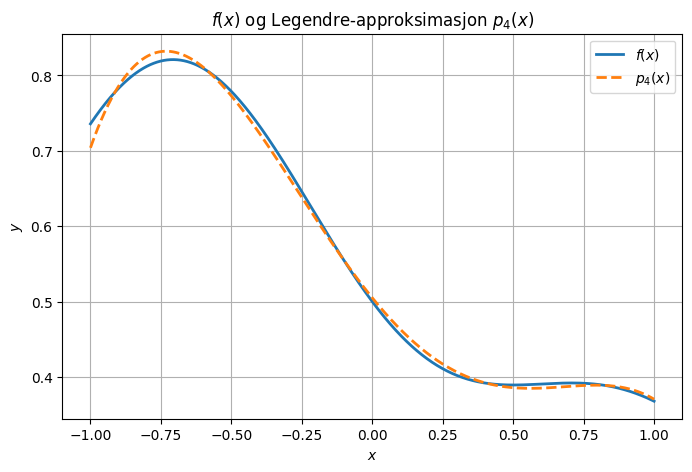

Estimert L²-feil  ||f - p₄||₂ ≈ 1.01e-02


In [61]:
xs = np.linspace(-1, 1, 1001)

# Legendre-approksimasjon p_4(x) via rekursjonsformelen
p4 = np.zeros(xs.size)
for k in range(5):
    p4 += a[k] * np.array(legendre(k, xs))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, f(xs), label='$f(x)$', linewidth=2)
ax.plot(xs, p4,   label='$p_4(x)$', linestyle='--', linewidth=2)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('$f(x)$ og Legendre-approksimasjon $p_4(x)$')
ax.legend()
ax.grid()
plt.show()

# L2-feil
h_plot = xs[1] - xs[0]
l2_error = np.sqrt(h_plot * np.sum((f(xs) - p4)**2))
print(f'Estimert L²-feil  ||f - p₄||₂ ≈ {l2_error:.2e}')


## Ekstra — Alternative integrasjonsmetoder

Midtpunktregelen kan byttes ut med en hvilken som helst annen numerisk integrasjonsmetode for å beregne $I_k$.  
Tabellen nedenfor viser aktuelle alternativer med funksjonskall, feilorden og krav.

| Metode | Funksjonskall | Feilorden | Krav / merknad |
|---|---|---|---|
| **Midtpunktregelen** (vår) | `midpoint(f, a, b, n)` | $O(h^2)$ | `h = (b−a)/(n−1)`, bruker `n−1` midtpunkter |
| **Trapesregelen** | `np.trapezoid(f(xs), xs)` | $O(h^2)$ | Krever NumPy ≥ 2.0 (`np.trapz` for eldre) |
| **Simpsons regel** | `scipy.integrate.simpson(f(xs), x=xs)` | $O(h^4)$ | Antall punkter bør være odde |
| **Adaptiv Gauss-Kronrod** | `scipy.integrate.quad(f, a, b)[0]` | ~maskinpresisjon | Returnerer `(verdi, feilestim.)` — ingen $n$ |
| **Gauss-Legendre** (fast) | `scipy.integrate.fixed_quad(f, a, b, n=5)[0]` | Eksakt for polynomer av grad $\leq 2n-1$ | God for polynomaktige integrander |

### Feilordener oppsummert

Hvis $h$ halveres (antall delintervaller dobles):

| Metode | Feilorden | Feil reduseres med |
|---|---|---|
| Rektangel (venstre Riemann) | $O(h)$ | faktor **2** |
| Midtpunkt / Trapes | $O(h^2)$ | faktor **4** |
| Simpsons regel | $O(h^4)$ | faktor **16** |
| Adaptiv / Gauss | ~maskinpresisjon | — |

### Steg E.1 — `integrate()`-funksjonen nedenfor

Funksjonen `integrate(f, a, b, n, metode)` samler alle metodene bak ett grensesnitt.  
Bytt `METODE`-variabelen øverst i cellen for å sammenligne resultater uten å endre resten av koden.

Valgt metode: trapes
Estimerte integraler I_k = integral av x^k * f(x) dx:
  I_0 = 1.1257442982
  I_1 = -0.1894723455
  I_2 = 0.3900589956
  I_3 = -0.1002933251
  I_4 = 0.2338559791

Estimert L2-feil  ||f - p4||_2 approx 1.01e-02


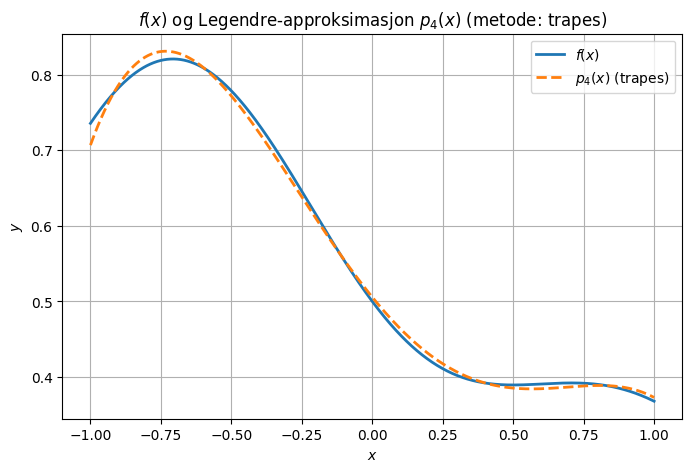

In [62]:

def integrate(f, a, b, n=101, metode="midtpunkt"):
    """
    Beregn integralet av f over [a, b].

    Parameters
    ----------
    f      : callable  -- funksjon av en variabel
    a, b   : float     -- integrasjonsgrenser
    n      : int       -- antall noder (brukes av midtpunkt, trapes, simpson)
    metode : str       -- en av:
               "midtpunkt"      -- midtpunktregelen (var opprinnelige)
               "trapes"         -- trapesregelen (np.trapezoid)
               "simpson"        -- Simpsons regel (scipy.integrate.simpson)
               "adaptiv"        -- adaptiv Gauss-Kronrod (scipy.integrate.quad)
               "gauss_legendre" -- fast Gauss-Legendre, n angir antall noder

    Returns
    -------
    float -- approksimert integralverdi
    """
    if metode == "midtpunkt":
        h = (b - a) / (n - 1)
        ms = np.arange(a + 0.5 * h, b, h)
        return h * np.sum(f(ms))

    elif metode == "trapes":
        xs = np.linspace(a, b, n)
        return np.trapezoid(f(xs), xs)

    elif metode == "simpson":
        n_odd = n if n % 2 == 1 else n + 1
        xs = np.linspace(a, b, n_odd)
        return simpson(f(xs), x=xs)

    elif metode == "adaptiv":
        verdi, _ = quad(f, a, b)
        return verdi

    elif metode == "gauss_legendre":
        verdi, _ = fixed_quad(f, a, b, n=n)
        return verdi

    else:
        raise ValueError(
            f"Ukjent metode: {metode!r}. "
            "Velg blant: 'midtpunkt', 'trapes', 'simpson', 'adaptiv', 'gauss_legendre'"
        )


# --- Bytt metode her ---
METODE =  "trapes"  # proev: "gauss_legendre", "adaptiv", "midtpunkt", "trapes", "simpson", "adaptiv", "gauss_legendre"

# Beregn I_k med valgt metode
print(f"Valgt metode: {METODE}")
print("Estimerte integraler I_k = integral av x^k * f(x) dx:")
I_alt = np.zeros(5)
for k in range(5):
    I_alt[k] = integrate(lambda x, k=k: x**k * f(x), a_int, b_int, n=101, metode=METODE)
    print(f"  I_{k} = {I_alt[k]:.10f}")

# Beregn Legendre-koeffisienter med formelen a_k = (2k+1)/2 * integral(P_k(x)*f(x))
a_alt = np.zeros(5)
for k in range(5):
    a_alt[k] = (2*k + 1) * integrate(lambda x, k=k: legendre(k, x) * f(x), a_int, b_int, n=101, metode=METODE) / 2

# Beregn p_4(x) med de nye koeffisientene via rekursjonsformelen
xs_alt = np.linspace(-1, 1, 1001)
p4_alt = np.zeros(xs_alt.size)
for k in range(5):
    p4_alt += a_alt[k] * np.array(legendre(k, xs_alt))

# L2-feil
h_alt = xs_alt[1] - xs_alt[0]
l2_alt = np.sqrt(h_alt * np.sum((f(xs_alt) - p4_alt)**2))
print(f"\nEstimert L2-feil  ||f - p4||_2 approx {l2_alt:.2e}")

# Plott
fig_alt, ax_alt = plt.subplots(figsize=(8, 5))
ax_alt.plot(xs_alt, f(xs_alt), label='$f(x)$', linewidth=2)
ax_alt.plot(xs_alt, p4_alt, label=f'$p_4(x)$ ({METODE})', linestyle='--', linewidth=2)
ax_alt.set_xlabel('$x$')
ax_alt.set_ylabel('$y$')
ax_alt.set_title(f'$f(x)$ og Legendre-approksimasjon $p_4(x)$ (metode: {METODE})')
ax_alt.legend()
ax_alt.grid()
plt.show()


## Ekstra — Velg grad på approksimasjonen

I stedet for å bruke alle fem Legendre-polynomer ($P_0$ til $P_4$) kan vi stoppe ved en lavere grad $M \leq 4$:

$$p_M(x) = \sum_{k=0}^{M} a_k P_k(x), \quad M \in \{0, 1, 2, 3, 4\}.$$

Koeffisientene $a_k$ er de samme som før — vi bruker bare færre av dem. Siden Legendre-basisen er ortogonal, endres ikke de eksisterende koeffisientene når vi legger til eller fjerner ledd; hvert $a_k$ bestemmes uavhengig.

Bytt `GRAD`-variabelen nedenfor for å se hvordan $L^2$-feilen vokser når vi bruker færre polynomer.

Grad M = 0:  estimert L²-feil ||f - p_0||₂ ≈ 2.46e-01

Sammenligning over alle grader:
  M = 0:  ||f - p_0||₂ ≈ 2.46e-01
  M = 1:  ||f - p_1||₂ ≈ 8.19e-02
  M = 2:  ||f - p_2||₂ ≈ 7.41e-02
  M = 3:  ||f - p_3||₂ ≈ 3.92e-02
  M = 4:  ||f - p_4||₂ ≈ 1.01e-02


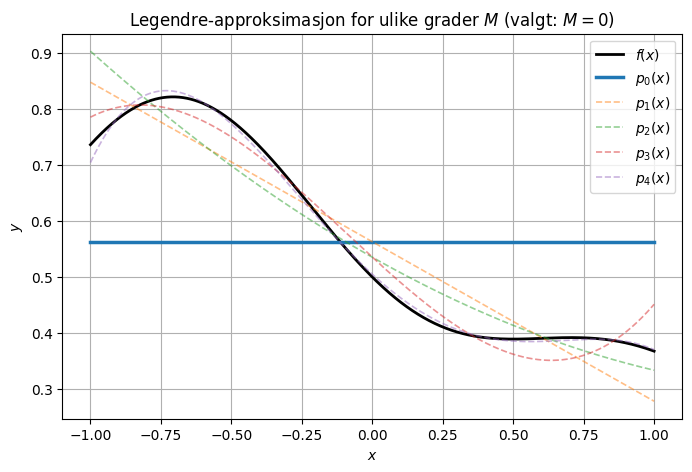

In [63]:
# --- Bytt grad her (0, 1, 2, 3 eller 4) ---
GRAD = 0  # prøv: 0, 1, 2, 3, 4

p_grad = np.zeros(xs.size)
for k in range(GRAD + 1):
    p_grad += a[k] * np.array(legendre(k, xs))

# L2-feil
h_g = xs[1] - xs[0]
l2_grad = np.sqrt(h_g * np.sum((f(xs) - p_grad)**2))
print(f"Grad M = {GRAD}:  estimert L²-feil ||f - p_{GRAD}||₂ ≈ {l2_grad:.2e}")

# Sammenlign alle grader
print("\nSammenligning over alle grader:")
for M in range(5):
    p_M = np.zeros(xs.size)
    for k in range(M + 1):
        p_M += a[k] * np.array(legendre(k, xs))
    err = np.sqrt(h_g * np.sum((f(xs) - p_M)**2))
    print(f"  M = {M}:  ||f - p_{M}||₂ ≈ {err:.2e}")

# Plott
fig_g, ax_g = plt.subplots(figsize=(8, 5))
ax_g.plot(xs, f(xs), label="$f(x)$", linewidth=2, color="black")
for M in range(5):
    p_M = np.zeros(xs.size)
    for k in range(M + 1):
        p_M += a[k] * np.array(legendre(k, xs))
    linestyle = "-" if M == GRAD else "--"
    linewidth = 2.5 if M == GRAD else 1.2
    alpha = 1.0 if M == GRAD else 0.5
    ax_g.plot(xs, p_M, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=f"$p_{M}(x)$")
ax_g.set_xlabel("$x$")
ax_g.set_ylabel("$y$")
ax_g.set_title(f"Legendre-approksimasjon for ulike grader $M$ (valgt: $M={GRAD}$)")
ax_g.legend(loc="upper right")
ax_g.grid()
plt.show()


## Ekstra — Samlet funksjon

Funksjonen `approksimer(n, grad, metode, basis)` kombinerer alle steg i én definisjon: numerisk integrasjon, koeffisientberegning og plotting.

| Parameter | Betydning | Eksempel |
|-----------|-----------|---------|
| `N` | Antall noder for integrasjon (delintervaller = N−1) | `101` |
| `GRAD` | Polynomdgrad (0–4) | `4` |
| `METODE` | Integrasjonsmetode | `"midtpunkt"` |
| `BASIS` | Approksimasjonstype | `"Legendre"` eller `"interpolasjon"` |

### To ulike strategier

| Basis | Prinsipp | Egenskap |
|-------|----------|---------|
| `"Legendre"` | $a_k = \frac{2k+1}{2}\int_{-1}^{1} f\,P_k\,dx$ | Minimerer $L^2$-feilen over hele intervallet |
| `"interpolasjon"` | $p(\xi_j) = f(\xi_j)$ for $j=0,\ldots,M$ | Passerer **eksakt** gjennom $M+1$ valgte noder |

For interpolasjon brukes **Chebyshev-noder** $\xi_j = \cos\!\left(\frac{(2j+1)\pi}{2(M+1)}\right)$, som reduserer Runges fenomen (store oscillasjoner nær endene) sammenlignet med ekvidistante noder.

n=13  |  grad=4  |  metode='midtpunkt'  |  basis='Legendre'
Koeffisienter:
  a_0 = 0.56331230
  a_1 = -0.28421063
  a_2 = 0.04782265
  a_3 = 0.12489759
  a_4 = -0.13389811
L²-feil  ||f - p_4||₂ ≈ 2.82e-02


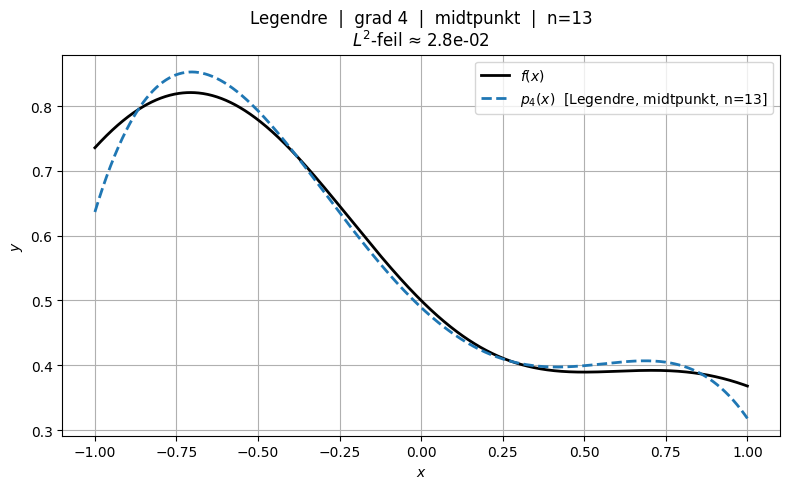

(array([ 0.5633123 , -0.28421063,  0.04782265,  0.12489759, -0.13389811]),
 array([0.63654987, 0.63985576, 0.64313075, ..., 0.32081321, 0.31937647,
        0.3179238 ], shape=(1001,)),
 np.float64(0.028217828781843753))

In [ ]:
# --- Konfigurer her ---
N      = 13              # antall noder  (delintervaller = N-1)
GRAD   = 4                # polynomdgrad  (vilkårlig ikke-negativ heltall)
METODE = "midtpunkt"      # prøv: "midtpunkt", "trapes", "simpson", "adaptiv", "gauss_legendre"
BASIS  = "Legendre"  # prøv: "Legendre", "interpolasjon"

# ---------------------------------------------------------------------------
# Hjelpefunksjoner
# ---------------------------------------------------------------------------

def _legendre_approks(grad, n, metode, xs_plot):
    """Beregn Legendre-approksimasjon og returner (a, p, noder=None)."""
    a = np.zeros(grad + 1)
    for k in range(grad + 1):
        a[k] = (2*k + 1) / 2 * integrate(
            lambda x, k=k: f(x) * np.array(legendre(k, x)),
            -1.0, 1.0, n=n, metode=metode,
        )
    p = sum(a[k] * np.array(legendre(k, xs_plot)) for k in range(grad + 1))

    print(f"n={n}  |  grad={grad}  |  metode='{metode}'  |  basis='Legendre'")
    print("Koeffisienter:")
    for k in range(grad + 1):
        print(f"  a_{k} = {a[k]:.8f}")

    return a, p, None


def _interpolasjon_approks(grad, xs_plot):
    """Beregn polynominterpolasjon i Chebyshev-noder og returner (None, p, noder)."""
    j = np.arange(grad + 1)
    noder = np.sort(np.cos((2*j + 1) * np.pi / (2*(grad + 1))))
    verdier = f(noder)
    p = np.polyval(np.polyfit(noder, verdier, grad), xs_plot)

    print(f"grad={grad}  |  basis='interpolasjon'  (Chebyshev-noder)")
    print("Interpolasjonsnoder og funksjonsverdier:")
    for xi, yi in zip(noder, verdier):
        print(f"  f({xi:+.4f}) = {yi:.8f}")

    return None, p, noder


# ---------------------------------------------------------------------------
# Samlet funksjon
# ---------------------------------------------------------------------------

def approksimer(n=101, grad=4, metode="midtpunkt", basis="Legendre"):
    """Beregn og plott en approksimasjon av f(x) på [-1, 1].

    Parameters
    ----------
    n      : int -- antall noder (brukes av Legendre)
    grad   : int -- polynomdgrad (vilkårlig ikke-negativ heltall)
    metode : str -- "midtpunkt" | "trapes" | "simpson" | "adaptiv" | "gauss_legendre"
    basis  : str -- "Legendre" | "interpolasjon"

    Returns
    -------
    a  : ndarray or None, p : ndarray, l2 : float
    """
    if basis not in ("Legendre", "interpolasjon"):
        raise ValueError(f"Ukjent basis: {basis!r}. Velg 'Legendre' eller 'interpolasjon'.")

    xs_plot = np.linspace(-1, 1, 1001)

    if basis == "Legendre":
        a, p, noder = _legendre_approks(grad, n, metode, xs_plot)
    else:
        a, p, noder = _interpolasjon_approks(grad, xs_plot)

    # L²-feil
    dx = xs_plot[1] - xs_plot[0]
    l2 = np.sqrt(dx * np.sum((f(xs_plot) - p)**2))
    print(f"L²-feil  ||f - p_{grad}||₂ ≈ {l2:.2e}")

    # Plott
    tittel = (
        f"Legendre  |  grad {grad}  |  {metode}  |  n={n}\n$L^2$-feil ≈ {l2:.1e}"
        if basis == "Legendre" else
        f"Interpolasjon  |  grad {grad}  |  Chebyshev-noder\n$L^2$-feil ≈ {l2:.1e}"
    )
    kurve_etikett = (
        f"$p_{{{grad}}}(x)$  [Legendre, {metode}, n={n}]"
        if basis == "Legendre" else
        f"$p_{{{grad}}}(x)$  [interpolasjon, Chebyshev]"
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(xs_plot, f(xs_plot), label="$f(x)$", linewidth=2, color="black")
    ax.plot(xs_plot, p, label=kurve_etikett, linestyle="--", linewidth=2)
    if noder is not None:
        ax.scatter(noder, f(noder), zorder=5, label="interpolasjonsnoder", color="tab:red")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.set_title(tittel)
    ax.legend()
    ax.grid()
    plt.tight_layout()
    plt.show()

    return a, p, l2


approksimer(N, GRAD, METODE, BASIS)


## Failsafe — alternativ løsning med hardkodede Legendre-polynomer

### Tilnærming: algebraiske formler i stedet for rekursjon

Denne varianten løser samme oppgave uten `legendre(n, x)`. I stedet skrives $P_k(x)$ ut eksplisitt som polynomer i $x$, og koeffisientene $a_k$ beregnes ved å sette inn de eksplisitte uttrykkene i integralformelen og gjenbruke $I_k$-verdiene fra Del 1 — ingen ny integrasjon er nødvendig.

| $k$ | $P_k(x)$ | $a_k$ fra $I_k$ |
|-----|----------|-----------------|
| 0 | $1$ | $a_0 = \tfrac{1}{2} I_0$ |
| 1 | $x$ | $a_1 = \tfrac{3}{2} I_1$ |
| 2 | $\tfrac{1}{2}(3x^2 - 1)$ | $a_2 = \tfrac{5}{4}(3 I_2 - I_0)$ |
| 3 | $\tfrac{1}{2}(5x^3 - 3x)$ | $a_3 = \tfrac{7}{4}(5 I_3 - 3 I_1)$ |
| 4 | $\tfrac{1}{8}(35x^4 - 30x^2 + 3)$ | $a_4 = \tfrac{9}{16}(35 I_4 - 30 I_2 + 3 I_0)$ |

**Fordel:** ingen ny integrasjon — $a_k$ følger algebraisk fra $I_k$-verdiene som allerede er beregnet.  
**Ulempe:** formlene er spesifikke for grad 4; en annen grad krever ny utregning.


Legendre-koeffisienter (hardkodet variant):
  a_0 = 0.5628905440
  a_1 = -0.2842085192
  a_2 = 0.0552189434
  a_3 = 0.1174851440
  a_4 = -0.0808301855


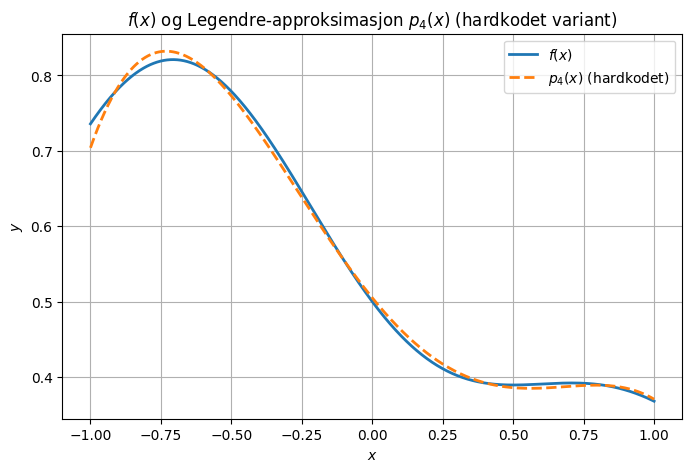

L²-feil  ||f - p₄||₂ ≈ 1.01e-02


In [65]:
# Koeffisienter algebraisk fra I_k (gjenbruker Del 1 — ingen ny integrasjon)
a_uttrykk = np.zeros(5)
a_uttrykk[0] = 1/2  * I[0]
a_uttrykk[1] = 3/2  * I[1]
a_uttrykk[2] = 5/4  * (3*I[2] - I[0])
a_uttrykk[3] = 7/4  * (5*I[3] - 3*I[1])
a_uttrykk[4] = 9/16 * (35*I[4] - 30*I[2] + 3*I[0])

print('Legendre-koeffisienter (hardkodet variant):')
for k in range(5):
    print(f'  a_{k} = {a_uttrykk[k]:.10f}')

# Legendre-polynomene som eksplisitte uttrykk
xs_uttrykk = np.linspace(-1, 1, 1001)
P0 = np.ones(xs_uttrykk.size)
P1 = xs_uttrykk
P2 = 0.5 * (3*xs_uttrykk**2 - 1)
P3 = 0.5 * (5*xs_uttrykk**3 - 3*xs_uttrykk)
P4 = (35*xs_uttrykk**4 - 30*xs_uttrykk**2 + 3) / 8

p4_uttrykk = a_uttrykk[0]*P0 + a_uttrykk[1]*P1 + a_uttrykk[2]*P2 + a_uttrykk[3]*P3 + a_uttrykk[4]*P4

fig_uttrykk, akse = plt.subplots(figsize=(8, 5))
akse.plot(xs_uttrykk, f(xs_uttrykk), label='$f(x)$', linewidth=2)
akse.plot(xs_uttrykk, p4_uttrykk, label='$p_4(x)$ (hardkodet)', linestyle='--', linewidth=2)
akse.set_xlabel('$x$')
akse.set_ylabel('$y$')
akse.set_title('$f(x)$ og Legendre-approksimasjon $p_4(x)$ (hardkodet variant)')
akse.legend()
akse.grid()
plt.show()

steglengde = xs_uttrykk[1] - xs_uttrykk[0]
l2_uttrykk = np.sqrt(steglengde * np.sum((f(xs_uttrykk) - p4_uttrykk)**2))
print(f'L²-feil  ||f - p₄||₂ ≈ {l2_uttrykk:.2e}')
